
# Bike Sharing Demand Analysis
## DSI Cohort 8 – Infrastructure & Transportation

This notebook follows the task described in the dataset README:
**Regression modeling to predict bike rental demand (`cnt`).**

We demonstrate two regression models:
- Linear Regression (baseline)
- Random Forest Regression

Alongside two advanced visualizations:
1. Demand Heatmap (Hour × Day of Week)
2. Seasonal Rental Distribution (Box Plot)


## 1. Load Libraries and Dataset

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

hour = pd.read_csv("hour_clean (1).csv")
hour.head()


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,cnt,season_label,weather_label,year_label,day_type_label,temp_celsius,humidity_pct,windspeed_kmh
0,1,1,0,1,0,0,6,0,1,0.24,...,0.81,0.0,16,Winter,Clear,2011,Weekend/Holiday,9.8,81.0,0.0
1,2,1,0,1,1,0,6,0,1,0.22,...,0.80,0.0,40,Winter,Clear,2011,Weekend/Holiday,9.0,80.0,0.0
2,3,1,0,1,2,0,6,0,1,0.22,...,0.80,0.0,32,Winter,Clear,2011,Weekend/Holiday,9.0,80.0,0.0
3,4,1,0,1,3,0,6,0,1,0.24,...,0.75,0.0,13,Winter,Clear,2011,Weekend/Holiday,9.8,75.0,0.0
4,5,1,0,1,4,0,6,0,1,0.24,...,0.75,0.0,1,Winter,Clear,2011,Weekend/Holiday,9.8,75.0,0.0



## 2. Visualization 1 — Demand Heatmap (Hour × Day of Week)

This visualization reveals **daily commuting patterns** and peak demand periods.


In [3]:
# Create Temperature Range

temp_col = 'temp_celsius' if 'temp_celsius' in hour.columns else 'temp'
if temp_col == 'temp':
    hour['temp_celsius'] = hour['temp'] * 41
    temp_col = 'temp_celsius'

bins = [0, 5, 10, 15, 20, 25, 30, 35, 45]
labels = ['0–5°C', '5–10°C', '10–15°C', '15–20°C', '20–25°C', '25–30°C', '30–35°C', '35–45°C']

hour['temp_bin'] = pd.cut(hour[temp_col], bins=bins, labels=labels, include_lowest=True)
hour[['hr', 'temp_celsius', 'temp_bin', 'cnt']].head()

,hr,temp_celsius,temp_bin,cnt
0,0,9.8,5–10°C,16
1,1,9.0,5–10°C,40
2,2,9.0,5–10°C,32
3,3,9.8,5–10°C,13
4,4,9.8,5–10°C,1


In [4]:
#Build the Heatmap Table

pivot = hour.pivot_table(
    values='cnt',
    index='temp_bin',
    columns='hr',
    aggfunc='mean',
    observed=False
)

pivot

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
temp_bin,,,,,,,,,,,,,,,,,,,,,
0–5°C,14.700000,8.272727,7.900000,4.000000,2.600000,6.812500,25.850000,74.476190,157.235294,109.076923,...,75.000000,103.000000,83.000000,67.000000,74.333333,90.250000,55.200000,42.000000,34.142857,20.800000
5–10°C,22.807229,15.527473,11.989899,7.369565,3.611111,10.852174,40.928000,113.623077,243.090909,137.900990,...,78.268293,81.500000,93.589744,147.181818,146.085106,100.791667,81.557377,62.447761,46.527027,34.815789
10–15°C,40.318750,28.173913,19.496774,9.453947,5.347222,16.352941,64.435065,189.359155,320.664286,196.923611,...,155.945946,161.111111,186.486726,275.065041,249.333333,180.309859,133.234899,106.393750,86.617284,60.871951
15–20°C,51.637795,30.960317,21.952000,11.305785,5.950000,21.333333,82.378151,221.413223,376.632479,216.672566,...,218.208000,215.590551,260.097561,367.091667,327.652893,252.883333,185.224138,148.495495,115.018182,79.752000
20–25°C,62.993197,40.500000,26.142857,13.076923,7.840000,24.891156,99.103448,274.395522,436.566929,263.285714,...,265.171875,287.333333,347.119048,524.200000,501.285714,351.325581,264.213740,204.237037,157.726619,106.374101
25–30°C,71.767857,44.024096,30.718750,15.581250,8.121795,25.682119,96.750000,267.631579,412.467949,256.515924,...,302.678832,316.213793,399.414966,590.992857,540.638710,404.451220,295.129412,230.574586,178.412088,123.052023
30–35°C,89.161290,43.320000,29.578947,18.133333,9.444444,19.666667,69.700000,248.407407,411.551020,245.357143,...,291.272727,298.090226,397.555556,607.197183,594.686441,451.570093,342.593023,265.701493,200.944444,123.439024
35–45°C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,209.666667,...,257.870370,265.370370,322.369565,512.771429,473.758621,405.071429,371.400000,218.500000,NaN,NaN


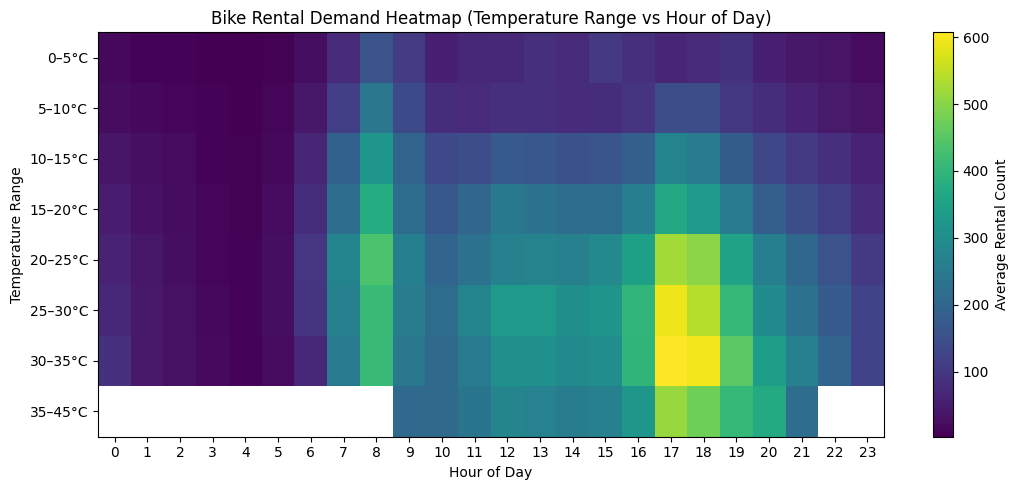

In [5]:

plt.figure(figsize=(11, 5))
plt.imshow(pivot, aspect='auto')
plt.title('Bike Rental Demand Heatmap (Temperature Range vs Hour of Day)')
plt.xlabel('Hour of Day')
plt.ylabel('Temperature Range')
plt.xticks(range(len(pivot.columns)), list(pivot.columns))
plt.yticks(range(len(pivot.index)), list(pivot.index))
plt.colorbar(label='Average Rental Count')
plt.tight_layout()
plt.show()


## Simple Interpretation

- Each **box** represents one combination of **temperature range** and **hour of day**
- **Brighter colors** mean **more bike rentals**
- **Darker colors** mean **fewer bike rentals**
- This helps identify **which hours and temperature conditions lead to the highest demand**


## 3. Visualization 2 — Seasonal Rental Distribution (Box Plot)

This plot shows the **spread, median, and outliers** of bike rental demand across seasons.


<Figure size 640x480 with 0 Axes>

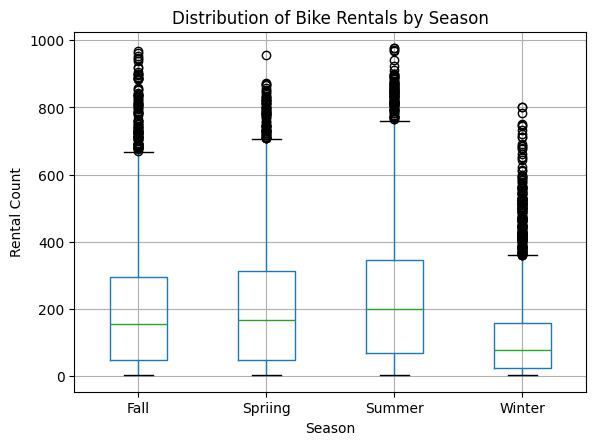

In [3]:

plt.figure()
hour.boxplot(column="cnt", by="season_label")
plt.title("Distribution of Bike Rentals by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Rental Count")
plt.show()



## 4. Prepare Data for Regression Models


In [4]:

features = [
"hr",
"workingday",
"temp_celsius",
"humidity_pct",
"windspeed_kmh"
]

X = hour[features]
y = hour["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## 5. Model 1 — Linear Regression (Baseline)


In [6]:

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_r2


0.3371103296566975


## 6. Model 2 — Random Forest Regression


In [9]:

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_r2


0.80686218961799


## 7. Model Comparison
Higher R² indicates better predictive performance.


In [8]:

print("Linear Regression R²:", lr_r2)
print("Random Forest R²:", rf_r2)


Linear Regression R²: 0.3371103296566975
Random Forest R²: 0.80686218961799
